# Hoạt động thực hành 1

## Nhận thức về dữ liệu và quy trình học máy

Notebook này thực hiện các yêu cầu trong tài liệu `Hoạt động thực hành 1.docx`:

- Nạp và kiểm tra dữ liệu từ `lab1_student_learning_records.csv`
- Tính thống kê mô tả cho các biến số
- Phân tích phân bố của `course_result`
- Tạo các biểu đồ để quan sát mối quan hệ giữa các chỉ số học tập và điểm thi cuối kỳ
- Viết sơ đồ quy trình học máy (ML workflow)

> Ghi chú: notebook này sử dụng `pandas` và `matplotlib`. Nếu kernel của bạn chưa có các thư viện đó, hãy cài đặt trước khi chạy.

In [1]:
# Nếu cần, bỏ comment dòng dưới để cài thư viện trong notebook
# %pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

## 1. Nạp dữ liệu

In [2]:
df = pd.read_csv('lab1_student_learning_records.csv')
df.head()

,student_id,attendance_rate,avg_quiz_score,assignment_completion_rate,study_hours_per_week,lms_logins_per_week,final_exam_score,course_result,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,S001,0.802709,69.579350,0.759963,10.807935,8,64.8,pass,NaN,NaN,NaN
1,S002,0.793965,73.622387,0.821814,12.654235,12,82.2,pass,NaN,NaN,NaN
2,S003,0.849561,90.355132,0.787498,7.574707,11,69.9,pass,NaN,NaN,NaN
3,S004,0.924809,68.631185,0.847788,8.992854,12,72.7,pass,NaN,NaN,NaN
4,S005,0.505607,63.503530,0.615154,11.504049,12,55.6,pass,NaN,NaN,NaN


## 2. Kiểm tra dữ liệu ban đầu

Ta cần xác định:

- Kích thước bảng dữ liệu
- Tên cột và kiểu dữ liệu
- Số lượng giá trị thiếu
- Cột đầu vào (features) và cột mục tiêu (target)

In [3]:
print('Kích thước dữ liệu:', df.shape)
print('\nTên các cột:')
print(df.columns.tolist())

print('\nThông tin kiểu dữ liệu:')
display(df.info())

print('\nSố lượng giá trị thiếu theo cột:')
display(df.isnull().sum())

Kích thước dữ liệu: (180, 11)

Tên các cột:
['student_id', 'attendance_rate', 'avg_quiz_score', 'assignment_completion_rate', 'study_hours_per_week', 'lms_logins_per_week', 'final_exam_score', 'course_result', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  180 non-null    str    
 1   attendance_rate             174 non-null    float64
 2   avg_quiz_score              177 non-null    float64
 3   assignment_completion_rate  180 non-null    float64
 4   study_hours_per_week        180 non-null    float64
 5   lms_logins_per_week         180 non-null    int64  
 6   final_exam_score            180 non-null    float64
 7   course_result               180 non-null    str    
 8   Unnamed: 8                  0 non-null      float64
 

None


Số lượng giá trị thiếu theo cột:


student_id                      0
attendance_rate                 6
avg_quiz_score                  3
assignment_completion_rate      0
study_hours_per_week            0
lms_logins_per_week             0
final_exam_score                0
course_result                   0
Unnamed: 8                    180
Unnamed: 9                    180
Unnamed: 10                   180
dtype: int64

In [4]:
feature_columns = [
    'attendance_rate',
    'avg_quiz_score',
    'assignment_completion_rate',
    'study_hours_per_week',
    'lms_logins_per_week'
]
regression_target = 'final_exam_score'
classification_target = 'course_result'

print('Các cột đầu vào (features):', feature_columns)
print('Biến mục tiêu cho bài toán dự đoán điểm:', regression_target)
print('Biến mục tiêu cho bài toán phân loại pass/fail:', classification_target)

print('Tất cả các cột trong tập tin', df.columns)


Các cột đầu vào (features): ['attendance_rate', 'avg_quiz_score', 'assignment_completion_rate', 'study_hours_per_week', 'lms_logins_per_week']
Biến mục tiêu cho bài toán dự đoán điểm: final_exam_score
Biến mục tiêu cho bài toán phân loại pass/fail: course_result
Tất cả các cột trong tập tin Index(['student_id', 'attendance_rate', 'avg_quiz_score',
       'assignment_completion_rate', 'study_hours_per_week',
       'lms_logins_per_week', 'final_exam_score', 'course_result',
       'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='str')


### Nhận xét ngắn

- Bộ dữ liệu có 180 dòng hồ sơ sinh viên tổng hợp.
- Có giá trị thiếu ở `attendance_rate` và `avg_quiz_score`, nên nếu xây dựng mô hình cần tiền xử lý trước.
- `final_exam_score` phù hợp cho bài toán hồi quy, còn `course_result` phù hợp cho bài toán phân loại.

## 3. Thống kê mô tả

In [5]:
numeric_columns = [
    'attendance_rate',
    'avg_quiz_score',
    'assignment_completion_rate',
    'study_hours_per_week',
    'lms_logins_per_week',
    'final_exam_score'
]

summary_stats = df[numeric_columns].agg(['mean', 'median', 'std', 'min', 'max']).T
summary_stats

,mean,median,std,min,max
attendance_rate,0.824787,0.817548,0.110942,0.505607,1.000000
avg_quiz_score,72.091619,72.856552,14.069385,35.858009,100.000000
assignment_completion_rate,0.753877,0.776309,0.157857,0.350000,1.000000
study_hours_per_week,7.444630,7.568953,3.918410,0.000000,17.264685
lms_logins_per_week,9.033333,9.000000,3.935088,0.000000,24.000000
final_exam_score,72.141111,71.950000,11.147727,39.700000,100.000000


In [6]:
course_result_counts = df['course_result'].value_counts()
course_result_counts

course_result
pass    175
fail      5
Name: count, dtype: int64

### Nhận xét về thống kê mô tả

- `final_exam_score` có trung bình xấp xỉ 72.14 và trung vị khoảng 71.95, cho thấy phân bố điểm khá tập trung quanh vùng trên trung bình.
- `attendance_rate` có trung bình khoảng 0.825, nghĩa là phần lớn sinh viên tham dự lớp tương đối tốt.
- `course_result` mất cân bằng lớp rõ rệt: số lượng `pass` lớn hơn rất nhiều so với `fail`.
- Cân bằng lớp quan trọng vì nếu dữ liệu nghiêng quá nhiều về một lớp, mô hình có thể đạt độ chính xác cao một cách đánh lừa chỉ bằng cách dự đoán lớp đa số.

## 4. Trực quan hóa dữ liệu

Phần này tạo nhiều hơn 4 biểu đồ để quan sát cả phân bố dữ liệu lẫn mối quan hệ với `final_exam_score`.

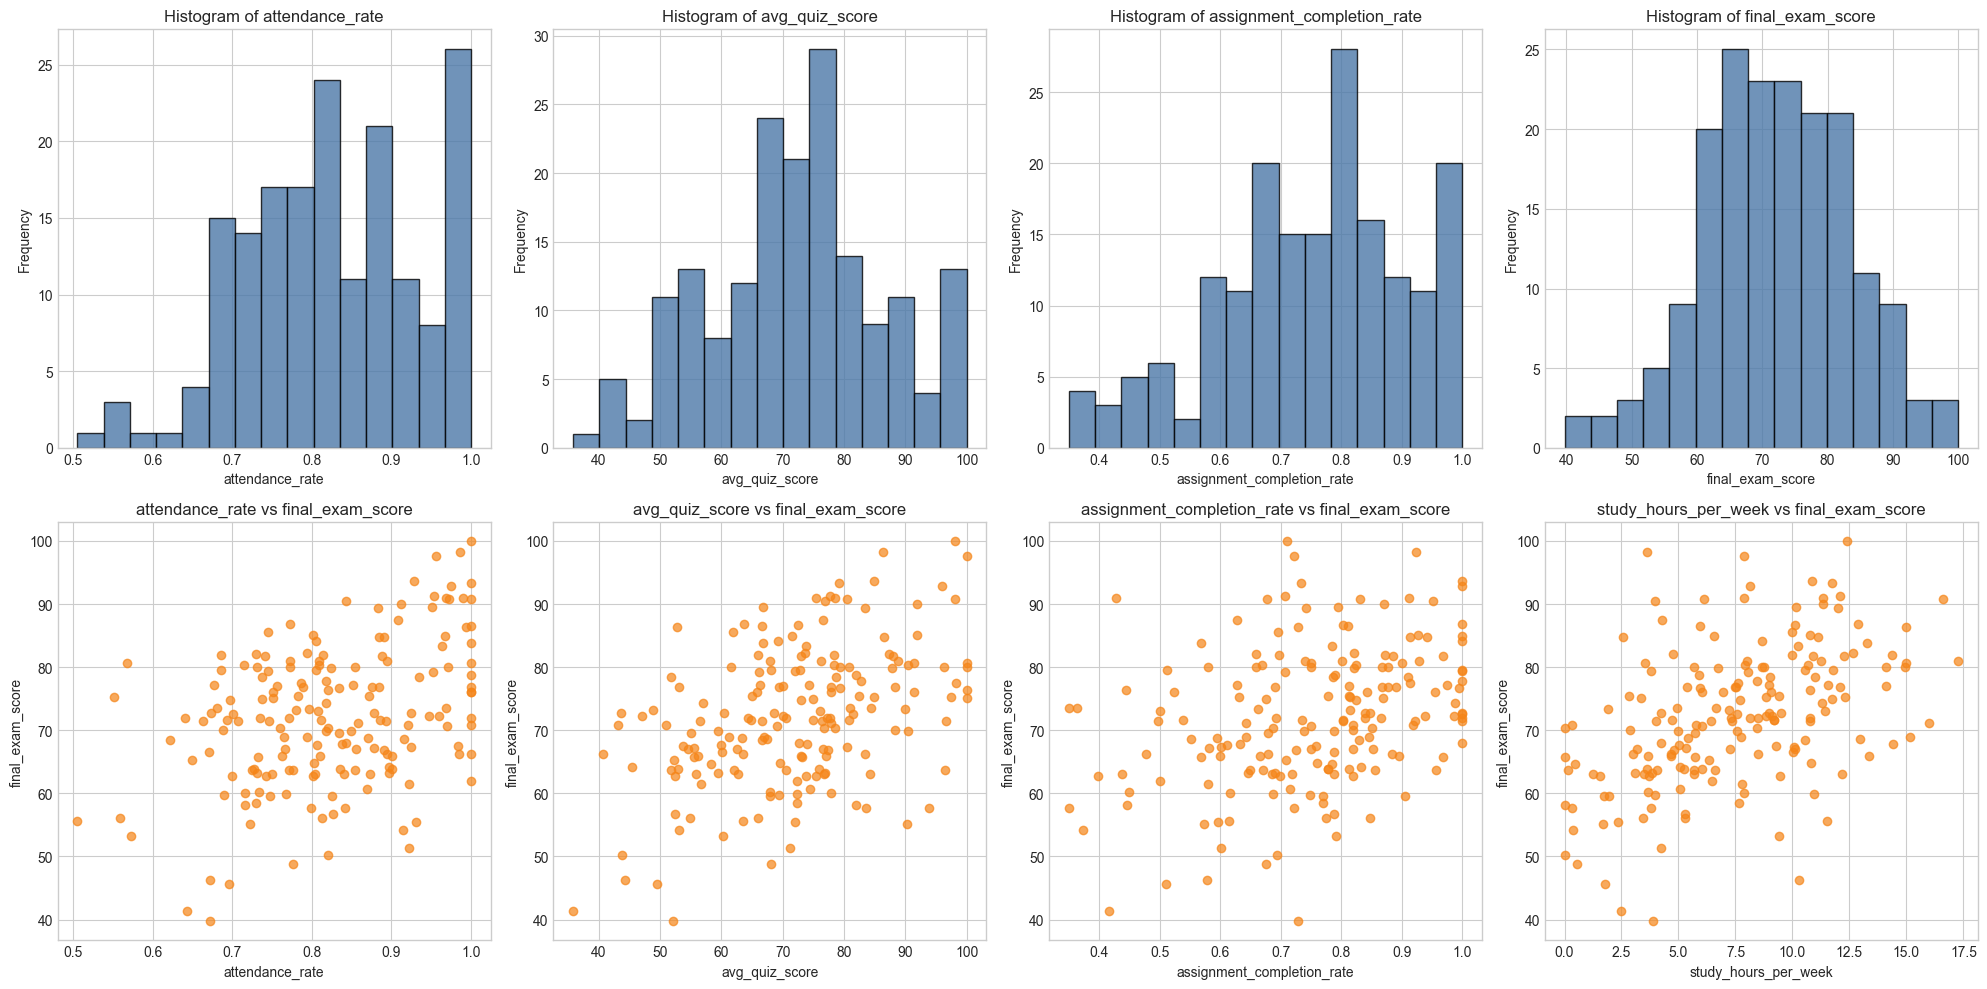

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

hist_columns = [
    'attendance_rate',
    'avg_quiz_score',
    'assignment_completion_rate',
    'final_exam_score'
]

for ax, col in zip(axes[0], hist_columns):
    ax.hist(df[col].dropna(), bins=15, color='#4C78A8', edgecolor='black', alpha=0.8)
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

scatter_columns = [
    'attendance_rate',
    'avg_quiz_score',
    'assignment_completion_rate',
    'study_hours_per_week'
]

for ax, col in zip(axes[1], scatter_columns):
    ax.scatter(df[col], df['final_exam_score'], color='#F58518', alpha=0.7)
    ax.set_title(f'{col} vs final_exam_score')
    ax.set_xlabel(col)
    ax.set_ylabel('final_exam_score')

plt.tight_layout()
plt.show()

In [8]:
correlation_with_final = df[feature_columns + ['final_exam_score']].corr(numeric_only=True)['final_exam_score'].sort_values(ascending=False)
correlation_with_final

final_exam_score              1.000000
study_hours_per_week          0.473820
avg_quiz_score                0.449416
attendance_rate               0.395297
assignment_completion_rate    0.350882
lms_logins_per_week           0.237506
Name: final_exam_score, dtype: float64

### Mô tả mẫu hình quan sát được

- Các biểu đồ phân tán cho thấy mối quan hệ dương mức vừa giữa `attendance_rate`, `avg_quiz_score`, `assignment_completion_rate`, `study_hours_per_week` và `final_exam_score`.
- Trong các biến quan sát, `study_hours_per_week` và `avg_quiz_score` thường thể hiện xu hướng đồng biến khá rõ với điểm cuối kỳ.
- Phân bố của `final_exam_score` tập trung nhiều ở vùng 65-85 điểm, ít điểm quá thấp hoặc quá cao.
- `attendance_rate` và `assignment_completion_rate` có xu hướng nằm ở mức tương đối cao, cho thấy đa số sinh viên trong dữ liệu có mức độ tham gia học tập tốt.
- Dữ liệu không cho thấy một quan hệ tuyến tính hoàn hảo, vì vậy nếu xây dựng mô hình thật cần đánh giá nhiều cách tiếp cận khác nhau.

## 5. Kết luận ngắn

Từ bước khám phá dữ liệu ban đầu, có thể thấy các chỉ số hành vi học tập và mức độ tham gia học tập có liên quan tích cực đến kết quả thi cuối kỳ. Tuy nhiên, dữ liệu có một số giá trị thiếu và phân bố `course_result` bị lệch mạnh về lớp `pass`, nên đây là những điểm cần xử lý nếu chuyển sang giai đoạn mô hình hóa.

## 6. Sơ đồ quy trình học máy (ML pipeline)

```text
Nguồn dữ liệu CSV
        |
        v
Nạp dữ liệu bằng pandas
        |
        v
Kiểm tra dữ liệu và làm sạch dữ liệu
(missing values, kiểu dữ liệu, ngoại lệ)
        |
        v
Tiền xử lý
(chọn biến, chuẩn hóa nếu cần, chia train/test)
        |
        v
Huấn luyện mô hình
(ví dụ: Linear Regression hoặc Random Forest)
        |
        v
Đánh giá mô hình
(MAE/RMSE cho hồi quy hoặc Accuracy/F1 cho phân loại)
        |
        v
Diễn giải kết quả và báo cáo cuối cùng
```

## 7. Gợi ý mở rộng

Nếu muốn phát triển notebook này thành bài thực hành tiếp theo, bạn có thể:

- Điền giá trị thiếu bằng trung bình hoặc trung vị
- Xây dựng mô hình dự đoán `final_exam_score`
- Xây dựng mô hình phân loại `course_result`
- So sánh nhiều mô hình và nhiều thước đo đánh giá

# 8. Huấn luyên mô hình dự đoán cơ bản để dự đoán điểm cuối kỳ

Trước hết ta tiền xử lý dữ liệu bằng việc bỏ cột không liên quan và chia dữ liệu ra 2 mẫu:
- Dữ liệu huấn luyện
- Dữ liệu kiểm tra 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

df = pd.read_csv("lab1_student_learning_records.csv")

df = df.drop(columns=["student_id"] + [c for c in df.columns if c.startswith("Unnamed")])

FEATURE_COLS = [
    "attendance_rate",
    "avg_quiz_score",
    "assignment_completion_rate",
    "study_hours_per_week",
    "lms_logins_per_week",
]
X = df[FEATURE_COLS]
y_reg = df["final_exam_score"]                        # Linear Regression target
y_clf = (df["course_result"] == "pass").astype(int)   # 1=pass, 0=fail
 
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURE_COLS)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=FEATURE_COLS)
print("\n  → Đã điền giá trị thiếu bằng trung vị (fitted trên tập train).")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# X_train_sc = X_train
# X_test_sc  = X_test

print("\n" + "=" * 55)
print("  LINEAR REGRESSION — Dự đoán final_exam_score")
print("=" * 55)
 
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
y_reg_pred = lr.predict(X_test_sc)
 
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2   = r2_score(y_reg_test, y_reg_pred)
 
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
 
print("\n  Hệ số hồi quy (đã chuẩn hoá, sắp xếp theo độ lớn):")
for feat, coef in sorted(zip(FEATURE_COLS, lr.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"    {feat:<35} {coef:+.4f}")
print(f"    {'Hệ số chặn (intercept)':<35} {lr.intercept_:+.4f}")


  → Đã điền giá trị thiếu bằng trung vị (fitted trên tập train).

  LINEAR REGRESSION — Dự đoán final_exam_score
  MAE  : 5.3206
  RMSE : 6.9157
  R²   : 0.5484

  Hệ số hồi quy (đã chuẩn hoá, sắp xếp theo độ lớn):
    study_hours_per_week                +5.0059
    attendance_rate                     +3.9804
    assignment_completion_rate          +3.3608
    avg_quiz_score                      +3.1882
    lms_logins_per_week                 +1.4814
    Hệ số chặn (intercept)              +72.0576


Phần này tính thông số mô hình trên dữ liệu huấn luyện thay vì sử dụng dữ liệu kiểm tra

Phần này lấy một điểm dữ liệu mẫu để dự đoán 

In [10]:
print(X_test_sc)

[[-1.26352665  0.51115559  0.78210213  0.54817042 -0.73839646]
 [-0.06903215  1.946426   -0.80970867  0.26224245  0.29142524]
 [ 0.13670097 -1.19600352  0.22564682 -1.67013095 -2.28312901]
 [-1.84658332 -0.37407439  0.49754566  0.70029121 -1.51076274]
 [-0.85031681  0.39479206 -0.4243412  -1.01045492 -0.22348561]
 [-0.06903215 -1.28686611  0.43027724 -1.18288173  1.06379151]
 [-0.0423957   2.14305102 -2.03599896  0.75535993 -0.22348561]
 [-0.66780281  1.49921806  1.31953497 -0.21782116  0.03396981]
 [-0.26120881  1.37763884 -0.59847304 -1.49845702  1.32124694]
 [-0.33071764  0.47089845  0.80452774 -0.08158382  2.09361321]
 [-0.67030967  2.14305102  0.75189578 -1.13689924 -0.73839646]
 [ 0.52593047  0.88539997 -0.07941971  1.06888118 -0.73839646]
 [ 1.45915046  1.11448536  1.11513907 -1.06558236  2.09361321]
 [-0.53508498  0.36839688 -0.02823062 -0.14061612  0.03396981]
 [-0.17253935 -0.88315176 -0.94373833 -0.70579447 -0.99585189]
 [ 1.44360399 -1.35244733  0.02510198  0.37670838  1.83

In [11]:
print(y_reg_test)

19     81.9
42     75.2
153    63.1
78     68.5
145    63.2
15     67.0
24     76.4
68     76.1
113    73.4
118    76.8
93     75.1
159    89.4
69     98.3
142    67.0
45     67.6
16     67.5
51     59.6
125    73.5
96     90.8
56     71.4
97     72.0
120    65.8
143    70.1
30     73.5
9      66.2
172    80.1
60     65.9
18     71.4
148    68.0
173    84.7
109    90.5
55     41.3
140    66.2
126    63.3
66     81.8
29     66.5
Name: final_exam_score, dtype: float64


In [12]:
print(y_reg_pred)

[72.93666503 77.01174744 57.80430345 66.45456008 63.11627486 64.78054382
 75.32912926 77.57391347 67.85490838 77.63938932 71.96394096 80.96391628
 82.9338067  70.35383737 60.3751266  78.18203307 64.93670872 66.64966913
 82.08513849 70.41886446 78.41155012 63.50756434 66.7460677  59.83322388
 68.51075689 83.67875548 77.88205606 63.37333448 71.94814966 72.8030288
 73.92412537 44.17317783 67.29852149 62.96931146 83.95732944 68.10798673]


In [13]:
sample_sc = [X_test_sc[0]]
x_sample_sc = sample_sc
y_sample_pred = lr.predict(x_sample_sc)
print(y_sample_pred)

[72.93666503]


In [14]:
sample_sc = [X_test_sc[1]]
x_sample_sc = sample_sc
y_sample_pred = lr.predict(x_sample_sc)
print(y_sample_pred)


[77.01174744]


In [15]:
sample_sc = [X_test_sc[3]]
x_sample_sc = sample_sc
y_sample_pred = lr.predict(x_sample_sc)
print(y_sample_pred)

[66.45456008]


In [16]:
sample_sc = [X_test_sc[4]]
x_sample_sc = sample_sc
y_sample_pred = lr.predict(x_sample_sc)
print(y_sample_pred)

[63.11627486]


In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_clf_train)
y_clf_pred      = log_reg.predict(X_test_sc)
y_clf_pred_prob = log_reg.predict_proba(X_test_sc)[:, 1]
 
acc = accuracy_score(y_clf_test, y_clf_pred)
print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"\n  Classification Report:")
print(classification_report(y_clf_test, y_clf_pred, target_names=["fail", "pass"]))
 
print("  Hệ số hồi quy (đã chuẩn hoá, sắp xếp theo độ lớn):")
for feat, coef in sorted(zip(FEATURE_COLS, log_reg.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f"    {feat:<35} {coef:+.4f}")

  Accuracy : 1.0000 (100.00%)

  Classification Report:
              precision    recall  f1-score   support

        fail       1.00      1.00      1.00         1
        pass       1.00      1.00      1.00        35

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

  Hệ số hồi quy (đã chuẩn hoá, sắp xếp theo độ lớn):
    attendance_rate                     +1.2561
    avg_quiz_score                      +1.1050
    lms_logins_per_week                 +0.8478
    study_hours_per_week                +0.7521
    assignment_completion_rate          +0.6014
